In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 77.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=2e143fca09b356cd18c4a1a1d86b5f88a84e070c5789fb898fc7acfb14c53c59
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


### Initial Setup and Imports

This cell handles the installation of necessary Qiskit packages and imports key modules.  
*   `%pip install qiskit`, `%pip install qiskit-aer`, `%pip install pylatexenc`: These commands install the Qiskit SDK, its simulator backend, and a LaTeX renderer for displaying quantum objects. The `%pip` syntax indicates these are shell commands executed within the Colab environment.
*   `from qiskit import QuantumCircuit, ...`: These lines import specific classes and functions from the Qiskit library, such as `QuantumCircuit` for building quantum circuits, `Statevector` for representing quantum states, `Operator` for representing unitary operations, and `plot_histogram` for visualizing measurement results.

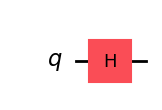

In [2]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

### Creating a Quantum Circuit with a Hadamard Gate

This code block demonstrates how to create a basic quantum circuit and apply a Hadamard gate.
*   `circuit = QuantumCircuit(1)`: This initializes a quantum circuit with 1 quantum bit (qubit) and 0 classical bits. The number inside the parenthesis specifies the number of qubits.
*   `circuit.h(0)`: This applies a Hadamard (H) gate to the qubit at index 0. The Hadamard gate creates a superposition, transforming the \(|0\rangle\) state to \(\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)\) and the \(|1\rangle\) state to \(\frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)\).
*   `circuit.draw("mpl")`: This method visualizes the quantum circuit. "mpl" specifies the Matplotlib backend for drawing, resulting in a graphical representation of the circuit.

### Simulating Statevector Evolution

This section shows how to simulate the effect of a quantum circuit on a quantum state using `Statevector`.
*   `state = Statevector.from_int(0, 2)`: This initializes a `Statevector` object. `0` means the initial state is \(|0\rangle\) (in a computational basis). `2` indicates that there are `2^1 = 2` possible basis states for a single qubit (i.e., it's a 1-qubit system). So, it starts in the \(|0\rangle\) state, which is mathematically represented as \(\begin{pmatrix} 1 \\ 0 \end{pmatrix}\).
*   `state = state.evolve(circuit)`: This applies the operations defined in the `circuit` to the `state` vector. After applying the Hadamard gate to \(|0\rangle\), the state evolves to \(\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)\), which is \(\begin{pmatrix} 1/\sqrt{2} \\ 1/\sqrt{2} \end{pmatrix}\).
*   `state.draw("latex")`: This displays the current `state` vector using LaTeX for a formatted mathematical representation. It will output \(\frac{\sqrt{2}}{2}|0\rangle + \frac{\sqrt{2}}{2}|1\rangle\).

In [3]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [4]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

### Alternate Statevector Display with `array_to_latex`

*   `array_to_latex(state)`: This function from `qiskit.visualization` takes a quantum object (like a `Statevector` or `Operator`) and renders its underlying array in a formatted LaTeX output. It provides an alternative way to visualize the state vector.

In [5]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

### Representing a Circuit as a Unitary Operator

Quantum circuits can also be viewed as unitary operators that transform quantum states.
*   `U = Operator(circuit)`: This converts the entire `circuit` into a `Operator` object, which represents the unitary transformation performed by the circuit. For a single Hadamard gate, the operator is \(H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}\).
*   `array_to_latex(U)`: Displays the matrix representation of the `Operator U` using LaTeX.

In [6]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

### Accessing the Raw Data of an Operator

*   `U.data`: This attribute of the `Operator` object `U` returns the underlying NumPy array representing the unitary matrix. This provides the raw numerical values of the operator, which in the case of the Hadamard gate is:  
    \(\begin{pmatrix} 0.70710678 & 0.70710678 \\ 0.70710678 & -0.70710678 \end{pmatrix}\)  
    where \(0.70710678 \approx 1/\sqrt{2}\).

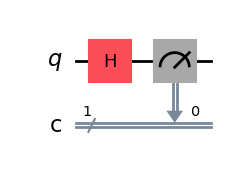

In [7]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

### Adding Measurement to a Quantum Circuit

To observe the outcome of a quantum computation, we need to measure the qubits. Measurements collapse the quantum state to a classical outcome.
*   `circuit = QuantumCircuit(1,1)`: This creates a new quantum circuit with 1 quantum bit and 1 classical bit. The classical bit is where the measurement outcome will be stored.
*   `circuit.h(0)`: A Hadamard gate is applied to qubit 0 to create a superposition, just as before.
*   `circuit.measure([0],[0])`: This performs a measurement operation. It measures the qubit at index `0` and stores the classical result in the classical bit at index `0`. The square brackets indicate lists, allowing for multiple qubits to be measured into multiple classical bits.

In [8]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

### Simulating and Running the Circuit

This block sets up and runs the quantum circuit on a simulator.
*   `backend = BasicSimulator()`: This initializes Qiskit's `BasicSimulator` as the execution environment for our circuit. This simulator mimics an ideal quantum computer.
*   `qc_compiled = transpile(circuit, backend)`: The `transpile` function optimizes the quantum circuit for the specific `backend`. It translates the circuit into the set of operations that the chosen backend can execute most efficiently.
*   `job_sim = backend.run(qc_compiled, shots=1024)`: This executes the `qc_compiled` circuit on the `backend` simulator. `shots=1024` specifies that the circuit should be run 1024 times. Each run is a single measurement, and we collect the statistics over these runs.
*   `result_sim = job_sim.result()`: This retrieves the results of the simulation job once it's completed. The results contain information like the measurement counts.

In [9]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'0': 505, '1': 519}


### Retrieving and Printing Measurement Counts

After running the simulation, we can access the measurement outcomes.
*   `counts = result_sim.get_counts(qc_compiled)`: This method from the `result_sim` object extracts the measurement results as a dictionary. The keys of the dictionary are the classical bit outcomes (e.g., '0' or '1'), and the values are the number of times each outcome was observed across all `shots`.
*   `print(counts)`: Displays the dictionary of measurement counts. For a Hadamard gate on \(|0\rangle\), we expect roughly 50% '0' and 50% '1' outcomes.

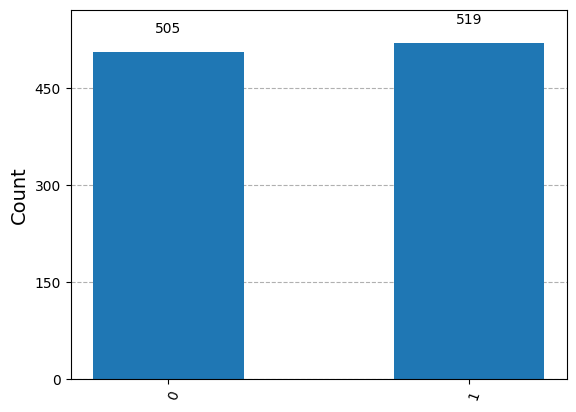

In [10]:
# We can also produce a graph

plot_histogram(counts)

### Visualizing Measurement Counts with a Histogram

*   `plot_histogram(counts)`: This function from `qiskit.visualization` generates a histogram from the `counts` dictionary. It's a convenient way to visually inspect the probabilities of different measurement outcomes.

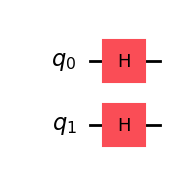

In [11]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

### Two-Qubit Circuit with Hadamard Gates

This expands the previous example to two qubits.
*   `circuit = QuantumCircuit(2)`: Creates a quantum circuit with 2 qubits.
*   `circuit.h(0)` and `circuit.h(1)`: Apply Hadamard gates to both qubit 0 and qubit 1 independently.  If both start in \(|0\rangle\), the combined state becomes \(|00\rangle\), and after two H-gates, it transforms to \(H \otimes H |00\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \otimes \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) = \frac{1}{2}(|00\rangle + |01\rangle + |10\rangle + |11\rangle)\).

In [12]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

### Statevector for Two Qubits

*   `state = Statevector.from_int(0, 4)`: Initializes a `Statevector` for a 2-qubit system (`2^2 = 4` basis states) starting in the \(|00\rangle\) state.
*   `state = state.evolve(circuit)`: Evolves the state using the 2-qubit circuit with two Hadamard gates.
*   `state.draw("latex")`: Displays the resulting state vector, which will be \(\frac{1}{2}(|00\rangle + |01\rangle + |10\rangle + |11\rangle)\).

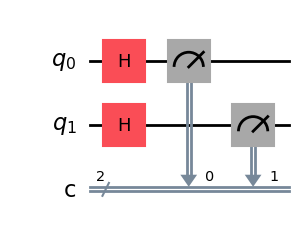

In [13]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

### Composing Circuits with Measurements

This demonstrates how to combine separate circuit components.
*   `meas = QuantumCircuit(2, 2)`: Creates a new circuit specifically for measurements, with 2 quantum bits and 2 classical bits.
*   `meas.measure(range(2), range(2))`: Measures all qubits (from index 0 to 1) into all classical bits (from index 0 to 1).
*   `qc = meas.compose(circuit, range(2), front=True)`: This is a powerful method for combining circuits.  
    *   `meas.compose(circuit, ...)`: `compose` adds `circuit` into `meas`.  
    *   `range(2)`: Specifies that `circuit` should be composed onto qubits 0 and 1 of `meas`.  
    *   `front=True`: This crucial parameter means that `circuit`'s operations are applied *before* `meas`'s operations. If `front=False` (default), `circuit` would be applied after `meas`.  
    The resulting `qc` is a single circuit that first applies the Hadamard gates and then performs the measurements.

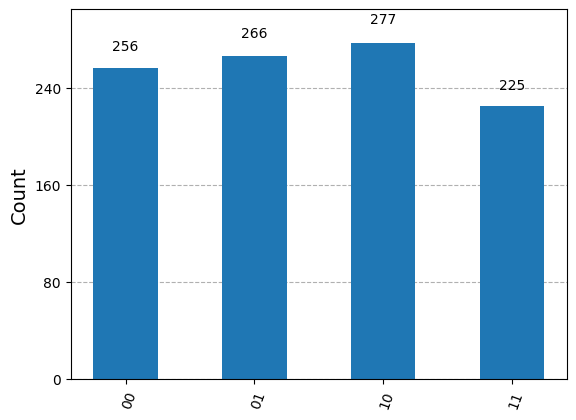

In [14]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

### Simulating the Composed Circuit

This block repeats the simulation process for the newly composed 2-qubit circuit with measurements.
*   `qc_compiled = transpile(qc, backend)`: Transpiles the `qc` circuit.
*   `job_sim = backend.run(qc_compiled, shots=1024)`: Runs the simulation.
*   `result_sim = job_sim.result()`: Gets the results.
*   `counts = result_sim.get_counts(qc_compiled)`: Extracts the measurement counts.  For the state \(\frac{1}{2}(|00\rangle + |01\rangle + |10\rangle + |11\rangle)\), each of the four possible outcomes ('00', '01', '10', '11') should have approximately equal counts.
*   `plot_histogram(counts)`: Visualizes the counts.

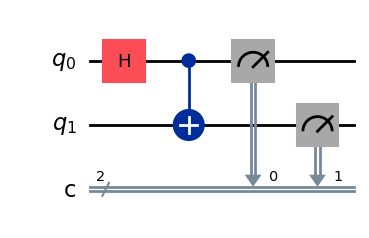

In [15]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

### Creating an Entangled Bell State

This section introduces entanglement by constructing a Bell state.
*   `circuit = QuantumCircuit(2,2)`: Creates a circuit with 2 qubits and 2 classical bits.
*   `circuit.h(0)`: Applies a Hadamard gate to qubit 0, putting it in superposition: \(\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)\). The overall state is \(\frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)\) (since qubit 1 is still \(|0\rangle\)).
*   `circuit.cx(0,1)`: This applies a Controlled-NOT (CNOT) gate. Qubit 0 is the control, and qubit 1 is the target. The CNOT gate flips the target qubit if and only if the control qubit is \(|1\rangle\).  
    *   If qubit 0 is \(|0\rangle\), qubit 1 remains \(|0\rangle\) (so \(|00\rangle\) remains \(|00\rangle\)).  
    *   If qubit 0 is \(|1\rangle\), qubit 1 flips from \(|0\rangle\) to \(|1\rangle\) (so \(|10\rangle\) becomes \(|11\rangle\)).  
    Combining these, the state \(\frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)\) transforms to \(\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)\). This is one of the four Bell states, characterized by strong entanglement.
*   `circuit.measure(range(2),range(2))`: Measures both qubits into both classical bits.

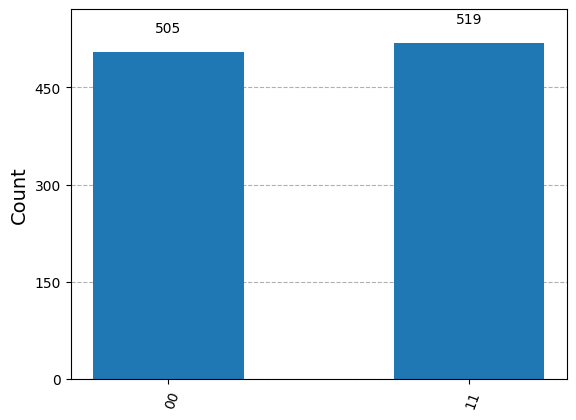

In [16]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

### Simulating the Bell State Circuit

This block simulates the Bell state circuit and visualizes its measurement outcomes.
*   The simulation steps are identical to the previous examples (`transpile`, `run`, `result`, `get_counts`, `plot_histogram`).  
*   For the Bell state \(\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)\), we expect only two outcomes: '00' and '11', each with approximately 50% probability. The outcomes '01' and '10' should be very rare or zero, demonstrating the perfect correlation (entanglement) between the two qubits.

In [20]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).

# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.

### Exercise 1: Creating the other Bell states

#### Bell State 1: \(\frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)\)

To create this state from the standard \(\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)\) Bell state, we apply a Z-gate to qubit 1. The Z-gate flips the phase of the \(|1\rangle\) state (i.e., \(Z|0\rangle = |0\rangle\) and \(Z|1\rangle = -|1\rangle\)).

Circuit steps:
1.  Initialize with two qubits.
2.  Apply Hadamard (H) gate to qubit 0: \(H|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)\). State becomes \(\frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)\).
3.  Apply CNOT (CX) gate with qubit 0 as control and qubit 1 as target. This creates \(\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)\).
4.  Apply Z gate to qubit 1: \(Z_1 \left( \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle) \right) = \frac{1}{\sqrt{2}}(|0\rangle \otimes Z|0\rangle + |1\rangle \otimes Z|1\rangle) = \frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)\).

Circuit for |00>-|11> Bell state:


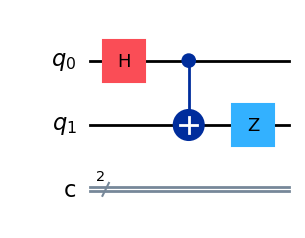

Statevector for |00>-|11> Bell state:


<IPython.core.display.Latex object>

Measurement counts for |00>-|11> Bell state: {'00': 535, '11': 489}


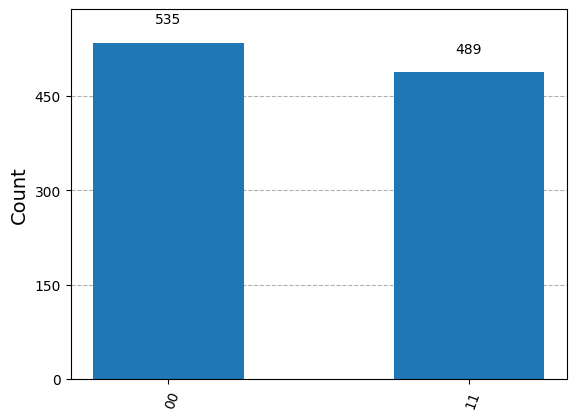

In [21]:
# Bell State: 1/sqrt(2) ( |00> - |11> )
circuit_bell_00_minus_11 = QuantumCircuit(2, 2)
circuit_bell_00_minus_11.h(0)
circuit_bell_00_minus_11.cx(0, 1)
circuit_bell_00_minus_11.z(1) # Apply Z gate to qubit 1

# Display the circuit
print("Circuit for |00>-|11> Bell state:")
display(circuit_bell_00_minus_11.draw("mpl"))

# Display the state vector
state_bell_00_minus_11 = Statevector.from_int(0, 4) # Start from |00>
state_bell_00_minus_11 = state_bell_00_minus_11.evolve(circuit_bell_00_minus_11)
print("Statevector for |00>-|11> Bell state:")
display(state_bell_00_minus_11.draw("latex"))

# Add measurements and simulate
circuit_bell_00_minus_11.measure(range(2), range(2))
qc_compiled = transpile(circuit_bell_00_minus_11, BasicSimulator())
job_sim = BasicSimulator().run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
print("Measurement counts for |00>-|11> Bell state:", counts)
display(plot_histogram(counts))

#### Bell State 2: \(\frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)\)

To achieve this state, we can start by flipping the second qubit to \(|1\rangle\) using an X-gate, resulting in an initial state of \(|01\rangle\). Then, we apply the Hadamard and CNOT gates as usual.

Circuit steps:
1.  Initialize with two qubits.
2.  Apply X-gate to qubit 1: \(X|0\rangle = |1\rangle\). Initial state becomes \(|01\rangle\).
3.  Apply Hadamard (H) gate to qubit 0: \(H|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)\). State becomes \(\frac{1}{\sqrt{2}}(|01\rangle + |11\rangle)\).
4.  Apply CNOT (CX) gate with qubit 0 as control and qubit 1 as target:
    *   If control is \(|0\rangle\), target \(|1\rangle\) remains \(|1\rangle\) (\(|01\rangle \rightarrow |01\rangle\)).
    *   If control is \(|1\rangle\), target \(|1\rangle\) flips to \(|0\rangle\) (\(|11\rangle \rightarrow |10\rangle\)).
    This results in \(\frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)\).

Circuit for |01>+|10> Bell state:


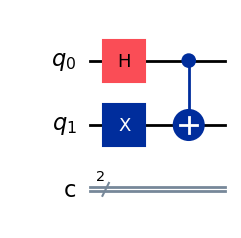

Statevector for |01>+|10> Bell state:


<IPython.core.display.Latex object>

Measurement counts for |01>+|10> Bell state: {'10': 517, '01': 507}


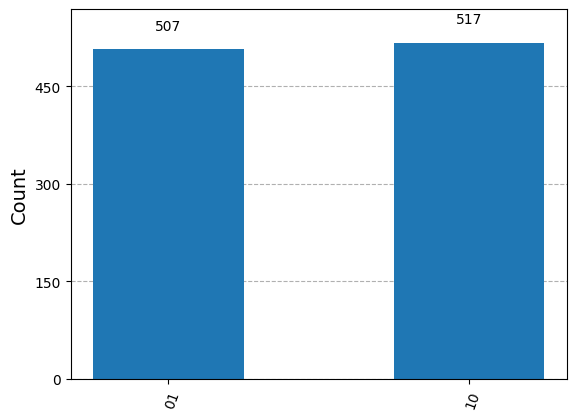

In [22]:
# Bell State: 1/sqrt(2) ( |01> + |10> )
circuit_bell_01_plus_10 = QuantumCircuit(2, 2)
circuit_bell_01_plus_10.x(1) # Start with |01> by flipping qubit 1
circuit_bell_01_plus_10.h(0)
circuit_bell_01_plus_10.cx(0, 1)

# Display the circuit
print("Circuit for |01>+|10> Bell state:")
display(circuit_bell_01_plus_10.draw("mpl"))

# Display the state vector
state_bell_01_plus_10 = Statevector.from_int(0, 4) # Start from |00>, then apply X
state_bell_01_plus_10 = state_bell_01_plus_10.evolve(circuit_bell_01_plus_10)
print("Statevector for |01>+|10> Bell state:")
display(state_bell_01_plus_10.draw("latex"))

# Add measurements and simulate
circuit_bell_01_plus_10.measure(range(2), range(2))
qc_compiled = transpile(circuit_bell_01_plus_10, BasicSimulator())
job_sim = BasicSimulator().run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
print("Measurement counts for |01>+|10> Bell state:", counts)
display(plot_histogram(counts))

#### Bell State 3: \(\frac{1}{\sqrt{2}}(|01\rangle - |10\rangle)\)

Similar to the previous state, we start by creating \(\frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)\). To introduce a minus sign to the \(|10\rangle\) term, we can apply a Z-gate to qubit 0. The Z-gate flips the phase of \(|1\rangle\) on qubit 0 while leaving \(|0\rangle\) unchanged.

Circuit steps:
1.  Initialize with two qubits.
2.  Apply X-gate to qubit 1: Initial state becomes \(|01\rangle\).
3.  Apply Hadamard (H) gate to qubit 0. State becomes \(\frac{1}{\sqrt{2}}(|01\rangle + |11\rangle)\).
4.  Apply CNOT (CX) gate. This creates \(\frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)\).
5.  Apply Z gate to qubit 0: \(Z_0 \left( \frac{1}{\sqrt{2}}(|01\rangle + |10\rangle) \right) = \frac{1}{\sqrt{2}}(Z|0\rangle \otimes |1\rangle + Z|1\rangle \otimes |0\rangle) = \frac{1}{\sqrt{2}}(|01\rangle - |10\rangle)\).

Circuit for |01>-|10> Bell state:


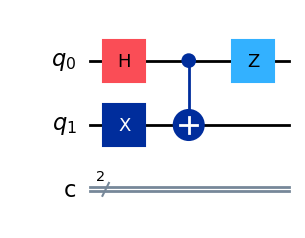

Statevector for |01>-|10> Bell state:


<IPython.core.display.Latex object>

Measurement counts for |01>-|10> Bell state: {'10': 516, '01': 508}


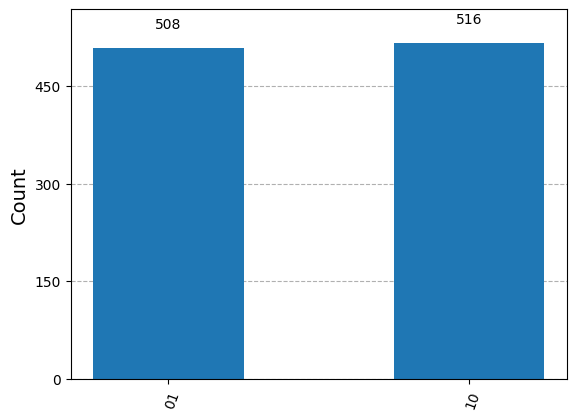

In [23]:
# Bell State: 1/sqrt(2) ( |01> - |10> )
circuit_bell_01_minus_10 = QuantumCircuit(2, 2)
circuit_bell_01_minus_10.x(1) # Start with |01>
circuit_bell_01_minus_10.h(0)
circuit_bell_01_minus_10.cx(0, 1)
circuit_bell_01_minus_10.z(0) # Apply Z gate to qubit 0

# Display the circuit
print("Circuit for |01>-|10> Bell state:")
display(circuit_bell_01_minus_10.draw("mpl"))

# Display the state vector
state_bell_01_minus_10 = Statevector.from_int(0, 4) # Start from |00>, then apply X
state_bell_01_minus_10 = state_bell_01_minus_10.evolve(circuit_bell_01_minus_10)
print("Statevector for |01>-|10> Bell state:")
display(state_bell_01_minus_10.draw("latex"))

# Add measurements and simulate
circuit_bell_01_minus_10.measure(range(2), range(2))
qc_compiled = transpile(circuit_bell_01_minus_10, BasicSimulator())
job_sim = BasicSimulator().run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
print("Measurement counts for |01>-|10> Bell state:", counts)
display(plot_histogram(counts))

In [24]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?

### Exercise 2: Generating a GHZ state for any number of qubits

The GHZ (Greenberger–Horne–Zeilinger) state is a maximally entangled quantum state involving three or more qubits. The general form is \(\frac{1}{\sqrt{2}}(|00...0\rangle + |11...1\rangle)\).

To construct an N-qubit GHZ state:
1.  Initialize an N-qubit circuit.
2.  Apply a Hadamard (H) gate to the first qubit (qubit 0). This puts qubit 0 into a superposition: \(\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)\).
3.  Apply a series of CNOT (CX) gates, where qubit 0 is the control qubit and each subsequent qubit (from qubit 1 to qubit N-1) is the target qubit. This effectively 'copies' the superposition from qubit 0 to all other qubits, creating the entangled GHZ state.

2-qubit GHZ state:
Simulating GHZ circuit with 2 qubits...


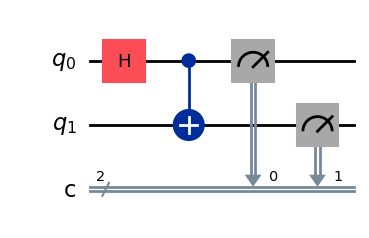

Measurement counts: {'00': 532, '11': 492}


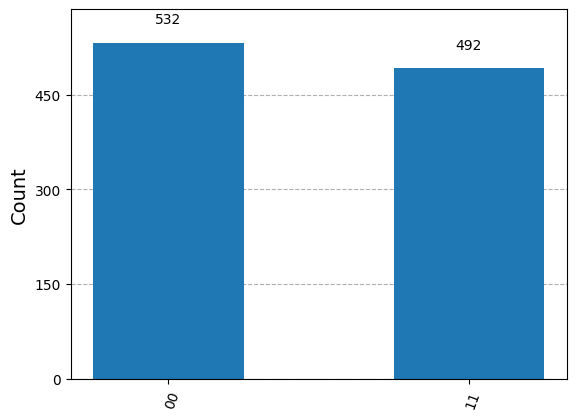


--------------------------------------------------

3-qubit GHZ state:
Simulating GHZ circuit with 3 qubits...


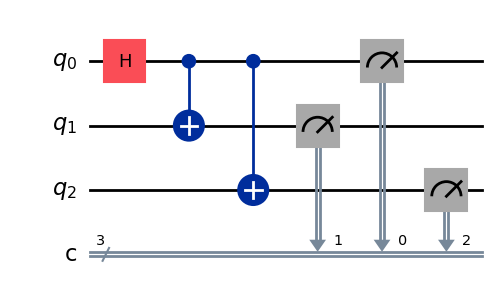

Measurement counts: {'111': 506, '000': 518}


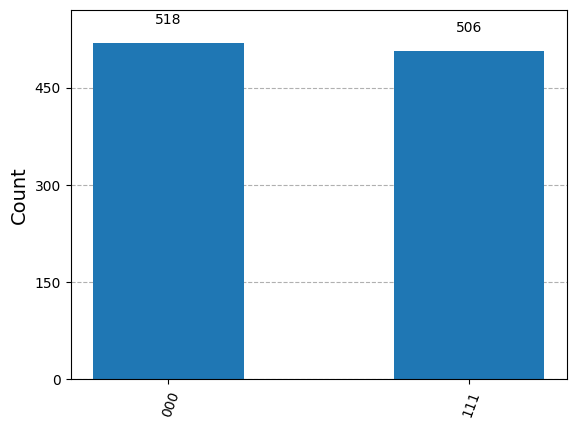


--------------------------------------------------

4-qubit GHZ state:
Simulating GHZ circuit with 4 qubits...


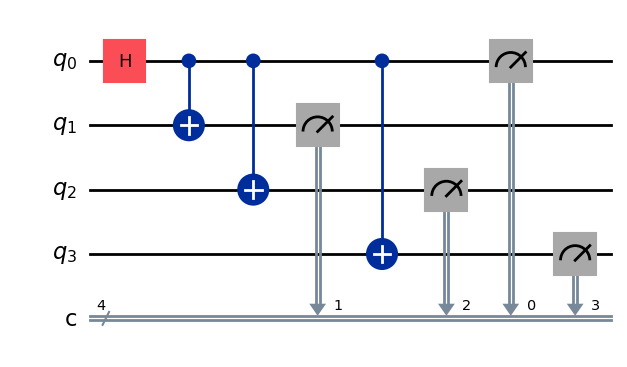

Measurement counts: {'1111': 500, '0000': 524}


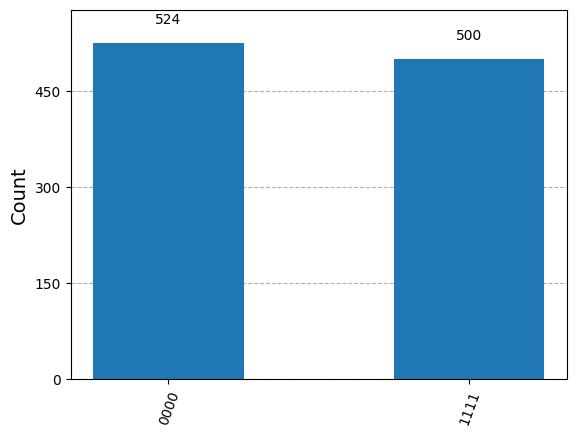


--------------------------------------------------



In [25]:
def create_ghz_circuit(num_qubits):
    """Creates an N-qubit GHZ state circuit."""
    circuit = QuantumCircuit(num_qubits, num_qubits)
    circuit.h(0) # Apply Hadamard to the first qubit

    # Apply CNOT gates to entangle all other qubits with the first
    for i in range(1, num_qubits):
        circuit.cx(0, i)

    circuit.measure(range(num_qubits), range(num_qubits))
    return circuit

def simulate_and_plot_ghz(ghz_circuit, shots=1024):
    """Simulates a GHZ circuit and plots the measurement histogram."""
    print(f"Simulating GHZ circuit with {ghz_circuit.num_qubits} qubits...")
    display(ghz_circuit.draw("mpl"))

    # Simulate the circuit
    backend = BasicSimulator()
    qc_compiled = transpile(ghz_circuit, backend)
    job_sim = backend.run(qc_compiled, shots=shots)
    result_sim = job_sim.result()
    counts = result_sim.get_counts(qc_compiled)

    print("Measurement counts:", counts)
    display(plot_histogram(counts))
    print("\n" + "-"*50 + "\n") # Separator for readability

# Test with different numbers of qubits

# 2-qubit GHZ state (which is a Bell state)
print("2-qubit GHZ state:")
ghz_2_qubits = create_ghz_circuit(2)
simulate_and_plot_ghz(ghz_2_qubits)

# 3-qubit GHZ state
print("3-qubit GHZ state:")
ghz_3_qubits = create_ghz_circuit(3)
simulate_and_plot_ghz(ghz_3_qubits)

# 4-qubit GHZ state
print("4-qubit GHZ state:")
ghz_4_qubits = create_ghz_circuit(4)
simulate_and_plot_ghz(ghz_4_qubits)

# Try with a larger number of qubits (e.g., 8 or more) to see performance
# This might take longer or require more memory depending on your environment.
# Uncomment and run to test limits
# print("8-qubit GHZ state:")
# ghz_8_qubits = create_ghz_circuit(8)
# simulate_and_plot_ghz(ghz_8_qubits)

# For typical local simulators and Colab environments, simulating beyond 20-25 qubits
# with a statevector simulator like BasicSimulator can become computationally intensive
# due to the exponential growth of the state space (2^N complex amplitudes).
# For larger numbers of qubits, more specialized simulators or approximation methods are needed.


### Simulator Capacity Observation

As you increase the number of qubits, you'll observe that the simulation time and memory usage grow rapidly. For a statevector simulator (which `BasicSimulator` uses under the hood), the statevector size is \(2^N\) complex amplitudes, where \(N\) is the number of qubits. This means:
*   For 2 qubits: \(2^2 = 4\) amplitudes.
*   For 3 qubits: \(2^3 = 8\) amplitudes.
*   For 4 qubits: \(2^4 = 16\) amplitudes.
*   For 8 qubits: \(2^8 = 256\) amplitudes.
*   For 20 qubits: \(2^{20} \approx 10^6\) amplitudes.

While the `BasicSimulator` in Qiskit is quite efficient for smaller numbers of qubits, it typically becomes impractical for systems with more than 20-25 qubits on standard hardware due to these exponential scaling factors. For larger qubit counts, one might use different types of simulators (e.g., those based on tensor networks) or run on actual quantum hardware.